In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import numpy as np
from tqdm import tqdm
import warnings
import os
import json
import glob
from typing import Optional, Tuple
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

In [ ]:
class FaceLandmarksDataset(Dataset):
    def __init__(
        self,
        root_dir: str,                     
        frames_per_video: int = 32,
        transform: Optional[callable] = None,
        cache_data: bool = False,
        include_contour: bool = True
    ):
        self.root_dir = root_dir
        self.frames_per_video = frames_per_video
        self.transform = transform
        self.cache_data = cache_data
        self.include_contour = include_contour

        self.num_mesh = 478
        self.num_contour = 36 if include_contour else 0
        self.num_landmarks = self.num_mesh + self.num_contour

        self.samples = []         
        self._collect_samples()

        self.cache = {} if cache_data else None
        self._empty_file_warnings = set()

        if self.cache is not None:
            for idx in range(len(self.samples)):
                self.cache[idx] = self._load_video_data(idx)

    def _collect_samples(self) -> None:
        for class_name in ["fake", "real"]:
            class_dir = os.path.join(self.root_dir, f"{class_name}_frames_faces")
            if not os.path.isdir(class_dir):
                print(f"Warning: directory not found: {class_dir}")
                continue

            label = 1 if class_name == "fake" else 0
            for video_folder in os.listdir(class_dir):
                video_path = os.path.join(class_dir, video_folder)
                if os.path.isdir(video_path):
                    self.samples.append((video_path, label))

        print(f"Total samples in {self.root_dir}: {len(self.samples)}")

    def _extract_landmarks_from_json(self, json_path: str) -> np.ndarray:
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)

            if "root" in data and isinstance(data["root"], dict):
                all_landmarks = data["root"].get("all_landmarks", [])
                contour_landmarks = data["root"].get("contour_landmarks", [])
            else:
                all_landmarks = data.get("all_landmarks", [])
                contour_landmarks = data.get("contour_landmarks", [])

            if not all_landmarks:
                if json_path not in self._empty_file_warnings:
                    warnings.warn(f"Empty or missing 'all_landmarks' in {json_path}")
                    self._empty_file_warnings.add(json_path)
                return np.zeros((self.num_landmarks, 3), dtype=np.float32)

            mesh_points = [[pt["x"], pt["y"], pt["z"]] for pt in all_landmarks]
            mesh_array = np.array(mesh_points, dtype=np.float32)

            if len(mesh_array) != self.num_mesh:
                if len(mesh_array) > self.num_mesh:
                    mesh_array = mesh_array[:self.num_mesh]
                else:
                    pad = np.zeros((self.num_mesh - len(mesh_array), 3), dtype=np.float32)
                    mesh_array = np.concatenate([mesh_array, pad], axis=0)

            if self.include_contour:
                if not contour_landmarks:
                    if json_path not in self._empty_file_warnings:
                        warnings.warn(f"Empty contour_landmarks in {json_path}")
                        self._empty_file_warnings.add(json_path)
                    contour_array = np.zeros((self.num_contour, 3), dtype=np.float32)
                else:
                    contour_points = [[pt["x"], pt["y"], pt["z"]] for pt in contour_landmarks]
                    contour_array = np.array(contour_points, dtype=np.float32)
                    if len(contour_array) != self.num_contour:
                        if len(contour_array) > self.num_contour:
                            contour_array = contour_array[:self.num_contour]
                        else:
                            pad = np.zeros((self.num_contour - len(contour_array), 3), dtype=np.float32)
                            contour_array = np.concatenate([contour_array, pad], axis=0)
                return np.concatenate([mesh_array, contour_array], axis=0)
            else:
                return mesh_array

        except Exception as e:
            if json_path not in self._empty_file_warnings:
                warnings.warn(f"Error reading {json_path}: {e}. Using zeros.")
                self._empty_file_warnings.add(json_path)
            return np.zeros((self.num_landmarks, 3), dtype=np.float32)

    def _load_video_data(self, idx: int) -> Tuple[torch.Tensor, int]:
        video_path, label = self.samples[idx]
        json_files = sorted(glob.glob(os.path.join(video_path, "frame_*.json")))

        if len(json_files) > self.frames_per_video:
            json_files = json_files[:self.frames_per_video]

        video_data = []
        for jf in json_files:
            video_data.append(self._extract_landmarks_from_json(jf))

        if len(video_data) < self.frames_per_video:
            if video_data:
                last_frame = video_data[-1]
            else:
                last_frame = np.zeros((self.num_landmarks, 3), dtype=np.float32)
            while len(video_data) < self.frames_per_video:
                video_data.append(last_frame.copy())

        video_array = np.stack(video_data, axis=0)
        tensor = torch.from_numpy(video_array).float()
        return tensor, label

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        if self.cache is not None:
        tensor, label = self.cache[idx]
        return tensor, torch.tensor(label, dtype=torch.float32)
    
    tensor, label = self._load_sample(idx)
    return tensor, torch.tensor(label, dtype=torch.float32)


def collate_fn(batch):
    videos, labels = zip(*batch)
    return torch.stack(videos, dim=0), torch.tensor(labels, dtype=torch.long)

In [ ]:
train_root = '/kaggle/input/datasets/mariaspasyuk/train-landmarks/train_faces_landmarks'
val_root   = '/kaggle/input/datasets/mariaspasyuk/val-landmarks/val_faces_landmarks'
test_root  = '/kaggle/input/datasets/mariaspasyuk/test-landmarks/test_faces_landmarks'

FRAMES_PER_VIDEO = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = FaceLandmarksDataset(root_dir=train_root, frames_per_video=FRAMES_PER_VIDEO, cache_data=False, include_contour=True, transform=None)
val_dataset = FaceLandmarksDataset(root_dir=val_root, frames_per_video=FRAMES_PER_VIDEO, cache_data=False, include_contour=True, transform=None)
test_dataset = FaceLandmarksDataset(root_dir=test_root, frames_per_video=FRAMES_PER_VIDEO, cache_data=False, include_contour=True, transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

for videos, labels in train_loader:
    print(f"Train batch: videos shape = {videos.shape}, labels = {labels}")
    break

for videos, labels in val_loader:
    print(f"Val batch: videos shape = {videos.shape}, labels = {labels}")
    break

for videos, labels in test_loader:
    print(f"Test batch: videos shape = {videos.shape}, labels = {labels}")
    break

In [4]:
def compute_stats(dataset):
    all_data = []
    for i in tqdm(range(len(dataset))):
        vid, _ = dataset[i]
        all_data.append(vid.numpy())
    all_data = np.concatenate(all_data)
    all_data = all_data.reshape(-1, 478*3)
    return torch.tensor(all_data.mean(axis=0)), torch.tensor(all_data.std(axis=0) + 1e-8)

mean, std = compute_stats(train_dataset)

class Norm:
    def __call__(self, x):
        x_flat = x.view(x.size(0), -1)
        x_flat = (x_flat - mean.to(x.device)) / std.to(x.device)
        return x_flat.view(x.shape)
"""
train_dataset.transform = Norm()
val_dataset.transform = Norm()
test_dataset.transform = Norm()
"""

100%|██████████| 7224/7224 [45:50<00:00,  2.63it/s]  


# Нормализация координат (выполняется 1 раз, данные сохраняются)

In [ ]:
"""
import torch
import numpy as np
from tqdm import tqdm
import pickle
from pathlib import Path

def save_normalized_dataset(dataset, save_path, dataset_name):
    
    all_videos = []
    all_labels = []
    
    for i in tqdm(range(len(dataset)), desc=f"Processing {dataset_name}"):
        video, label = dataset[i]
        all_videos.append(video.cpu().numpy())  
        all_labels.append(label)
    
    all_videos = np.array(all_videos, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)
    
    save_file = Path(save_path) / f"{dataset_name}_normalized.npz"
    np.savez_compressed(
        save_file,
        videos=all_videos,
        labels=all_labels,
        mean=mean.numpy(), 
        std=std.numpy()
    )
    
    print(f"Файл: {save_file}")
    print(f"Форма видео: {all_videos.shape}")
    print(f"Форма меток: {all_labels.shape}")
    print(f"Размер файла: {save_file.stat().st_size / 1024**2:.2f} мб")
    
    return save_file

save_path = '/kaggle/working/normalized_datasets'
Path(save_path).mkdir(parents=True, exist_ok=True)

train_file = save_normalized_dataset(train_dataset, save_path, 'train')
val_file = save_normalized_dataset(val_dataset, save_path, 'val')
test_file = save_normalized_dataset(test_dataset, save_path, 'test')

# Загрузка нормализованных координат

In [ ]:
class NormalizedLandmarksDataset(torch.utils.data.Dataset):
    
    def __init__(self, npz_file_path):
        print(f"Загрузка датасета из {npz_file_path}")

        data = np.load(npz_file_path)
        
        self.videos = torch.tensor(data['videos'], dtype=torch.float32)
        self.labels = torch.tensor(data['labels'], dtype=torch.long)

        if 'mean' in data and 'std' in data:
            self.mean = torch.tensor(data['mean'], dtype=torch.float32)
            self.std = torch.tensor(data['std'], dtype=torch.float32)
            print(f"Параметры нормализации: mean.shape={self.mean.shape}, std.shape={self.std.shape}")
        
        print(f"Видео: {self.videos.shape}")
        print(f"Метки: {self.labels.shape}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.videos[idx], self.labels[idx]

train_dataset_saved = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/train_normalized.npz')
val_dataset_saved = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/val_normalized.npz')
test_dataset_saved = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/test_normalized.npz')

sample_video, sample_label = train_dataset_saved[0]
print(f"Форма видео: {sample_video.shape}, метка {sample_label}")

# BiLSTM c attention

In [12]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)
        
    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attn(lstm_output), dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights

class BiLSTMWithAttention(nn.Module):
    def __init__(
        self, 
        input_dim=478*3, 
        hidden_dim=256, 
        num_layers=2, 
        dropout=0.3, 
        num_classes=2
    ):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.input_norm = nn.BatchNorm1d(input_dim)

        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers,
            batch_first=True, 
            bidirectional=True, 
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = Attention(hidden_dim * 2)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch, seq_len, lm, coords = x.shape

        x = x.view(batch, seq_len, lm * coords)

        x = x.transpose(1, 2)
        x = self.input_norm(x)
        x = x.transpose(1, 2)

        lstm_out, (hidden, cell) = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        output = self.classifier(context)
        
        return output

In [13]:
def compute_metrics(y_true, y_pred_proba):
    y_pred = (y_pred_proba[:, 1] >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred_proba[:, 1])
    except:
        auc = 0.5
    return acc, precision, recall, f1, auc

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for videos, labels in tqdm(loader, desc='Train'):
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.append(torch.softmax(outputs, dim=1).cpu().detach().numpy())
        all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc, prec, recall, f1, auc = compute_metrics(all_labels, all_preds)
    
    return total_loss / len(loader), acc, prec, recall, f1, auc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(loader, desc='Val'):
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.softmax(outputs, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc, prec, recall, f1, auc = compute_metrics(all_labels, all_preds)
    
    return total_loss / len(loader), acc, prec, recall, f1, auc


def test_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(loader, desc='Test'):
            videos = videos.to(device)
            outputs = model(videos)
            all_preds.append(torch.softmax(outputs, dim=1).cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc, prec, recall, f1, auc = compute_metrics(all_labels, all_preds)
    
    return acc, prec, recall, f1, auc

In [57]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-4, weight_decay=1e-5, device='cuda'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    best_val_auc = 0.0
    best_model_path = 'best_bilstm_model.pth'
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_auc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Current lr: {optimizer.param_groups[0]['lr']:.6f}")

        train_loss, train_acc, train_prec, train_rec, train_f1, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)

        val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = validate_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)

        print(f"Train: loss={train_loss:.4f}, acc={train_acc:.4f}, "
              f"Precision={train_prec:.4f}, Recall={train_rec:.4f}, F1={train_f1:.4f}, AUC={train_auc:.4f}")
        print(f"Val: loss={val_loss:.4f}, acc={val_acc:.4f}, "
              f"Precision={val_prec:.4f}, Recall={val_rec:.4f}, F1={val_f1:.4f}, AUC={val_auc:.4f}")

        scheduler.step(val_f1)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 
                        'val_f1': val_f1, 'val_acc': val_acc, 'history': history}, best_model_path)
            print(f"Saved best model with val AUC={val_auc:.4f}")

    checkpoint = torch.load(best_model_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Best val AUC: {best_val_auc:.4f}")
    
    return model, history

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2)
    axes[1, 0].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('F1 Score', fontsize=12)
    axes[1, 0].set_title('F1 Score over Epochs', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(epochs, history['train_auc'], 'b-', label='Train AUC', linewidth=2)
    axes[1, 1].plot(epochs, history['val_auc'], 'r-', label='Val AUC', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('AUC', fontsize=12)
    axes[1, 1].set_title('AUC over Epochs', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранён в {save_path}")
    
    plt.show()

In [19]:
from torch.utils.data import DataLoader

train_dataset = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/train_normalized.npz')
val_dataset = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/val_normalized.npz')
test_dataset = NormalizedLandmarksDataset('/kaggle/working/normalized_datasets/test_normalized.npz')

sample_video, sample_label = train_dataset[0]
print(f"Форма видео{sample_video.shape}, метка {sample_label}")

Загрузка датасета из /kaggle/working/normalized_datasets/train_normalized.npz...
   Загружены параметры нормализации: mean.shape=torch.Size([1434]), std.shape=torch.Size([1434])
   Видео: torch.Size([7224, 32, 478, 3])
   Метки: torch.Size([7224])
Загрузка датасета из /kaggle/working/normalized_datasets/val_normalized.npz...
   Загружены параметры нормализации: mean.shape=torch.Size([1434]), std.shape=torch.Size([1434])
   Видео: torch.Size([600, 32, 478, 3])
   Метки: torch.Size([600])
Загрузка датасета из /kaggle/working/normalized_datasets/test_normalized.npz...
   Загружены параметры нормализации: mean.shape=torch.Size([1434]), std.shape=torch.Size([1434])
   Видео: torch.Size([2116, 32, 478, 3])
   Метки: torch.Size([2116])

Проверка: видео форма torch.Size([32, 478, 3]), метка 1


In [20]:
BATCH_SIZE = 64
NUM_WORkeRS = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
    
model = BiLSTMWithAttention(input_dim=478*3, hidden_dim=256, num_layers=3, dropout=0.3, num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

trained_model, history = train_model(model, train_loader, val_loader, epochs=30, lr=1e-4, weight_decay=1e-5, device=device)

In [31]:
print("Testing model")
acc, prec, recall, f1, auc = test_model(trained_model, test_loader, device)
print (f'Test acc: {acc}, Test precision: {prec}, Test recall: {recall}, Test f1: {f1}, Test auc: {auc}')

Testing model:


Test: 100%|██████████| 34/34 [00:00<00:00, 45.61it/s]

Test acc: 0.744328922495274, Test precision: 0.8950086058519794, Test recall: 0.7128169979437972, Test f1: 0.7935902327355971, Test auc: 0.8413896634858637


In [ ]:
plot_training_history(history, save_path='training_history.png')

# Увеличим dropout до 0.4 

In [ ]:
model_v2 = BiLSTMWithAttention(input_dim=478*3, hidden_dim=256, num_layers=3, dropout=0.4, num_classes=2).to(device)

total_params = sum(p.numel() for p in model_v2.parameters())
trainable_params = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)

trained_model_v2, history_v2 = train_model(model_v2, train_loader, val_loader, epochs=30, lr=1e-4, weight_decay=1e-5, device=device)

In [32]:
print("Testing model_v2:")
acc_v2, prec_v2, recall_v2, f1_v2, auc_v2 = test_model(trained_model_v2, test_loader, device)
print (f'Test acc: {acc_v2}, Test precision: {prec_v2}, Test recall: {recall_v2}, Test f1: {f1_v2}, Test auc: {auc_v2}')

Testing model_v2:


Test: 100%|██████████| 34/34 [00:00<00:00, 43.38it/s]

Test acc: 0.7405482041587902, Test precision: 0.8902229845626072, Test recall: 0.7114461960246744, Test f1: 0.7908571428571428, Test auc: 0.8341538323511339


In [ ]:
plot_training_history(history_v2, save_path='training_history_v2.png')

# Увеличим регуляризацию до 1е-4 и уменьшим размерность скрытых слоев

In [ ]:
model_v3 = BiLSTMWithAttention(input_dim=478*3, hidden_dim=128, num_layers=3, dropout=0.3, num_classes=2).to(device)

trained_model_v3, history_v3 = train_model(model_v3, train_loader, val_loader, epochs=30, lr=1e-4, weight_decay=1e-4, device=device)

In [ ]:
plot_training_history(history_v3, save_path='training_history_v3.png')

In [45]:
print("Тesting model_v3:")
acc_v3, prec_v3, recall_v3, f1_v3, auc_v3 = test_model(trained_model_v3, test_loader, device)
print (f'Test acc: {acc_v3}, Test precision: {prec_v3}, Test recall: {recall_v3}, Test f1: {f1_v3}, Test auc: {auc_v3}')

Testing model_v3:


Test: 100%|██████████| 34/34 [00:00<00:00, 55.52it/s]

Test acc: 0.7367674858223062, Test precision: 0.8991150442477877, Test recall: 0.6963673749143249, Test f1: 0.7848590189262263, Test auc: 0.8275825376109864


# Увеличим dropout

In [ ]:
model_v4 = BiLSTMWithAttention(input_dim=478*3, hidden_dim=128, num_layers=2, dropout=0.4, num_classes=2).to(device)

total_params = sum(p.numel() for p in model_v4.parameters())
trainable_params = sum(p.numel() for p in model_v4.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемях параметров: {trainable_params:,}")

trained_model_v4, history_v4 = train_model(model_v4, train_loader, val_loader, epochs=50, lr=1e-5, weight_decay=1e-5, device=device)

График сохранён в training_history_v4.png


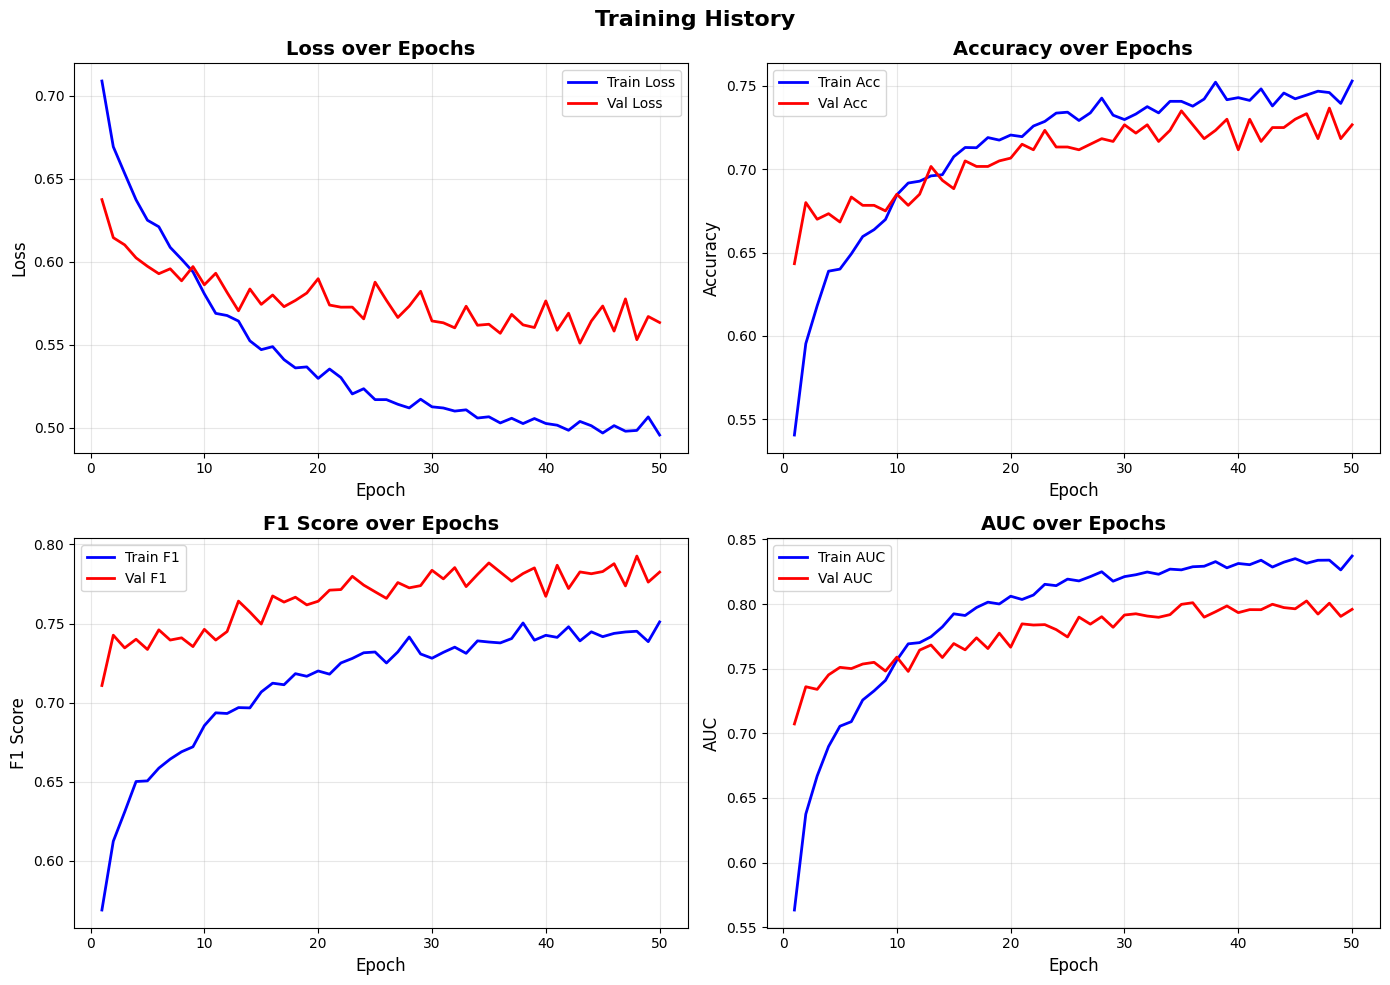

In [59]:
plot_training_history(history_v4, save_path='training_history_v4.png')

In [60]:
print("Testing model_v4:")
acc_v4, prec_v4, recall_v4, f1_v4, auc_v4 = test_model(trained_model_v4, test_loader, device)
print (f'Test acc: {acc_v4}, Test precision: {prec_v4}, Test recall: {recall_v4}, Test f1: {f1_v4}, Test auc: {auc_v4}')

Testing model_v4:


Test: 100%|██████████| 34/34 [00:00<00:00, 57.43it/s]

Test acc: 0.6895085066162571, Test precision: 0.8826335877862596, Test recall: 0.6339958875942426, Test f1: 0.7379337854008775, Test auc: 0.7853881278538812


In [ ]:
plot_training_history(history_v4, save_path='training_history_v4.png')

In [55]:
print("Testing model_v4:")
acc_v4, prec_v4, recall_v4, f1_v4, auc_v4 = test_model(trained_model_v4, test_loader, device)
print (f'Test acc: {acc_v4}, Test precision: {prec_v4}, Test recall: {recall_v4}, Test f1: {f1_v4}, Test auc: {auc_v4}')

Testing model_v4:


Test: 100%|██████████| 34/34 [00:00<00:00, 55.23it/s]

Test acc: 0.6724952741020794, Test precision: 0.8807157057654076, Test recall: 0.6072652501713502, Test f1: 0.7188640973630832, Test auc: 0.7768346994407254


In [ ]:
model_v5 = BiLSTMWithAttention(input_dim=478*3, hidden_dim=192, num_layers=3, dropout=0.5, num_classes=2).to(device)

trained_model_v5, history_v5 = train_model(model_v5, train_loader, val_loader, epochs=40, lr=5e-6, weight_decay=1e-4, device=device)

In [ ]:
plot_training_history(history_v5, save_path='training_history_v5.png')

# Трансформерная модель

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerForLandmarks(nn.Module):

    def __init__(
        self,
        input_dim=478*3,          
        d_model=256,               
        nhead=8,                  
        num_layers=4,             
        dim_feedforward=512,     
        dropout=0.3,
        num_classes=2,
        max_seq_len=32
    ):
        super().__init__()
        
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model, max_seq_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',    
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        batch, seq_len, lm, coords = x.shape

        x = x.view(batch, seq_len, lm * coords)
        x = self.input_projection(x) 
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        output = self.classifier(x)
        
        return output


class TransformerWithClsToken(nn.Module):

    def __init__(
        self,
        input_dim=478*3,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=512,
        dropout=0.3,
        num_classes=2,
        max_seq_len=32
    ):
        super().__init__()
        
        self.d_model = d_model
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.pos_encoder = PositionalEncoding(d_model, max_seq_len + 1, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for p in self.parameters():
            if p.dim() > 1 and p is not self.cls_token:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        batch, seq_len, lm, coords = x.shape
        x = x.view(batch, seq_len, lm * coords)

        x = self.input_projection(x)

        cls_tokens = self.cls_token.expand(batch, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        x = self.pos_encoder(x)
        x = self.transformer(x)

        cls_output = x[:, 0, :] 
        return self.classifier(cls_output)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, d_model, nhead=8):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, d_model))
    
    def forward(self, x):
        batch = x.size(0)
        query = self.query.expand(batch, -1, -1)
        context, _ = self.attention(query, x, x)
        return context.squeeze(1)


class TransformerWithAttentionPooling(nn.Module):
    def __init__(
        self,
        input_dim=478*3,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=512,
        dropout=0.3,
        num_classes=2,
        max_seq_len=32
    ):
        super().__init__()
        
        self.d_model = d_model
        
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model, max_seq_len, dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attention_pool = MultiHeadAttentionPooling(d_model, nhead)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        batch, seq_len, lm, coords = x.shape
        x = x.view(batch, seq_len, lm * coords)
        
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.attention_pool(x
        
        return self.classifier(x)

In [70]:
def train_transformer_model(train_loader, val_loader, model_type='base', epochs=50, lr=1e-4, device='cuda')

    if model_type == 'base':
        model = TransformerForLandmarks(input_dim=478*3, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.3, num_classes=2).to(device)
        
    elif model_type == 'cls_token':
        model = TransformerWithClsToken(input_dim=478*3, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.3, num_classes=2).to(device)
        
    elif model_type == 'attention_pool':
        model = TransformerWithAttentionPooling(input_dim=478*3, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.3, num_classes=2).to(device)
        
    else:
        raise ValueError(f"Неизвестный параметр: {model_type}")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4, betas=(0.9, 0.999))

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    criterion = nn.CrossEntropyLoss()
    
    best_val_auc = 0
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_auc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        train_loss, train_acc, train_f1, train_auc = train_epoch_transformer(model, train_loader, criterion, optimizer, device)

        val_loss, val_acc, val_f1, val_auc = validate_epoch_transformer(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        print(f"Train: loss={train_loss:.4f}, acc={train_acc:.4f}, F1={train_f1:.4f}, AUC={train_auc:.4f}")
        print(f"Val: loss={val_loss:.4f}, acc={val_acc:.4f}, F1={val_f1:.4f}, AUC={val_auc:.4f}")
        
        scheduler.step()
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f'best_transformer_{model_type}.pth')
            print(f"Saved best model with AUC={val_auc:.4f}")
    
    return model, history


def train_epoch_transformer(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for videos, labels in tqdm(loader, desc='Train'):
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.append(torch.softmax(outputs, dim=1).cpu().detach().numpy())
        all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    acc, _, _, f1, auc = compute_metrics(all_labels, all_preds)
    
    return total_loss / len(loader), acc, f1, auc


def validate_epoch_transformer(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(loader, desc='Val'):
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.softmax(outputs, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    acc, _, _, f1, auc = compute_metrics(all_labels, all_preds)
    
    return total_loss / len(loader), acc, f1, auc

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model_transformer, history_transformer = train_transformer_model(train_loader, val_loader, model_type='base', epochs=30,  lr=1e-5,  device=device)

In [ ]:
model_cls, history_cls = train_transformer_model(train_loader, val_loader, model_type='cls_token', epochs=20, lr=1e-5, device=device)

In [ ]:
model_attn_pool, history_attn_pool = train_transformer_model(train_loader, val_loader, model_type='attention_pool', epochs=20, lr=1e-5, device=device)